In [1]:
# Cell 1: Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import pickle
import time
import random
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Thư viện scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Thư viện xử lý ảnh
from skimage.feature import hog
from skimage import exposure, io, color, transform
from skimage.util import img_as_ubyte

# Thư viện visualization bổ sung
import matplotlib
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Thiết lập thông số hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Thiết lập seed cho reproducibility
np.random.seed(42)
random.seed(42)

In [2]:
# Cell 2: Thiết lập đường dẫn dataset Kaggle
# Trên Kaggle, dataset đã được mount tại /kaggle/input/
raw_img_path = '/kaggle/input/animalcs231/archive/raw-img/'

print(f"Đường dẫn dataset: {raw_img_path}")

# List các thư mục trong raw-img
raw_img_contents = sorted([d for d in os.listdir(raw_img_path) 
                          if os.path.isdir(os.path.join(raw_img_path, d))])
print(f"\nTìm thấy {len(raw_img_contents)} thư mục trong '{raw_img_path}':")
for folder in raw_img_contents:
    num_files = len([f for f in os.listdir(os.path.join(raw_img_path, folder)) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder:15} - {num_files:4d} files")

Đường dẫn dataset: /kaggle/input/animalcs231/archive/raw-img/

Tìm thấy 10 thư mục trong '/kaggle/input/animalcs231/archive/raw-img/':
  cane            - 4863 files
  cavallo         - 2623 files
  elefante        - 1446 files
  farfalla        - 2112 files
  gallina         - 3098 files
  gatto           - 1668 files
  mucca           - 1866 files
  pecora          - 1820 files
  ragno           - 4821 files
  scoiattolo      - 1862 files


In [3]:
# Cell 3: Thiết lập bảng dịch tên (Italian -> English)
translation_table = {
    "cane": "dog",
    "cavallo": "horse", 
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "ragno": "spider"
}

# Kiểm tra bản dịch
print("Bảng dịch tên thư mục (Italian -> English):")
for ita, eng in translation_table.items():
    print(f"{ita:12} -> {eng}")

Bảng dịch tên thư mục (Italian -> English):
cane         -> dog
cavallo      -> horse
elefante     -> elephant
farfalla     -> butterfly
gallina      -> chicken
gatto        -> cat
mucca        -> cow
pecora       -> sheep
scoiattolo   -> squirrel
ragno        -> spider


In [4]:
# Cell 4: Hàm load dataset
def load_dataset(dataset_path, translation_table):
    """
    Load ảnh từ cấu trúc thư mục và tạo DataFrame
    
    Args:
        dataset_path: Đường dẫn đến thư mục raw-img
        translation_table: Bảng dịch tên Italian -> English
        
    Returns:
        DataFrame chứa đường dẫn ảnh và nhãn
    """
    image_paths = []
    labels = []
    
    print("Bắt đầu load dataset...")
    print("-" * 50)
    
    # Duyệt qua các thư mục động vật
    for ita_label in tqdm(animal_folders, desc="Processing folders"):
        label_path = os.path.join(dataset_path, ita_label)
        
        if os.path.isdir(label_path):
            eng_label = translation_table[ita_label]
            
            # Lấy danh sách file ảnh
            image_files = [f for f in os.listdir(label_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # Thêm đường dẫn và nhãn
            for img_file in tqdm(image_files, desc=f"  {eng_label}", leave=False):
                img_path = os.path.join(label_path, img_file)
                image_paths.append(img_path)
                labels.append(eng_label)
    
    # Tạo DataFrame
    df = pd.DataFrame({
        'image_path': image_paths,
        'label': labels
    })
    
    print(f"\n✓ Đã load {len(df)} ảnh")
    print(f"✓ Số lượng theo từng class:")
    print(df['label'].value_counts())
    
    return df

In [5]:
# Cell 5: Hàm trích xuất HOG features
def extract_hog_features(image_paths, target_size=(128, 128)):
    """
    Trích xuất HOG features từ danh sách đường dẫn ảnh
    
    Args:
        image_paths: List đường dẫn ảnh
        target_size: Kích thước ảnh đầu vào (height, width)
    
    Returns:
        np.array: Ma trận features (n_samples, n_features)
    """
    features = []
    failed_images = []
    
    print(f"\nTrích xuất HOG features từ {len(image_paths)} ảnh...")
    print(f"Kích thước ảnh: {target_size}")
    
    # HOG parameters
    orientations = 9
    pixels_per_cell = (16, 16)
    cells_per_block = (2, 2)
    
    for i, img_path in enumerate(tqdm(image_paths, desc="Processing images")):
        try:
            # 1. Đọc ảnh grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                failed_images.append(img_path)
                continue
            
            # 2. Resize ảnh
            img = cv2.resize(img, target_size)
            
            # 3. Trích xuất HOG features
            hog_features = hog(
                img,
                orientations=orientations,
                pixels_per_cell=pixels_per_cell,
                cells_per_block=cells_per_block,
                block_norm='L2-Hys',
                transform_sqrt=True,
                feature_vector=True,
                visualize=False
            )
            
            features.append(hog_features)
            
        except Exception as e:
            failed_images.append(img_path)
            continue
    
    if failed_images:
        print(f"\n⚠ Không đọc được {len(failed_images)} ảnh")
    
    # Chuyển sang numpy array
    features_array = np.array(features)
    
    print(f"\n✓ Đã trích xuất features từ {len(features)} ảnh")
    print(f"✓ Shape của feature matrix: {features_array.shape}")
    
    return features_array

In [6]:
# Cell 6: Load dataset
print("=" * 60)
print("BẮT ĐẦU XỬ LÝ DATASET")
print("=" * 60)

# Sửa lại hàm load_dataset để khắc phục lỗi
def load_dataset(dataset_path, translation_table):
    """
    Load images from directory structure:
    dataset_path/
        cavallo/
        pecora/
        elefante/
        ...
    """
    
    image_paths = []
    labels = []
    
    # Get all folders in the dataset path
    all_folders = os.listdir(dataset_path)
    
    # Iterate through the directories in raw_img_path (each directory is a label)
    for label in tqdm(all_folders, desc='Loading folders'):
        label_path = os.path.join(dataset_path, label)
        # Check if it's a directory and in translation table
        if os.path.isdir(label_path) and label in translation_table:
            # Get files in the directory
            files = os.listdir(label_path)
            # Iterate through the files in the label directory
            for image_file in files:
                # Check if it's an image file
                if image_file.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif')):
                    image_path = os.path.join(label_path, image_file)
                    # Check if it's a file
                    if os.path.isfile(image_path):
                        image_paths.append(image_path)
                        labels.append(translation_table[label])
    
    # Create a pandas DataFrame
    df = pd.DataFrame({'image_path': image_paths, 'label': labels})
    
    print(f"\n✓ Đã load {len(df)} ảnh")
    print(f"✓ Phân bố theo class:")
    class_counts = df['label'].value_counts()
    for label, count in class_counts.items():
        print(f"  {label:15}: {count:4d} ảnh")
    
    return df

# Load dataset
data = load_dataset(raw_img_path, translation_table)

# Hiển thị 5 dòng đầu
print("\n5 dòng đầu của DataFrame:")
print(data.head())
print(f"\nTổng số ảnh: {len(data)}")

BẮT ĐẦU XỬ LÝ DATASET


Loading folders: 100%|██████████| 10/10 [00:30<00:00,  3.00s/it]


✓ Đã load 26179 ảnh
✓ Phân bố theo class:
  dog            : 4863 ảnh
  spider         : 4821 ảnh
  chicken        : 3098 ảnh
  horse          : 2623 ảnh
  butterfly      : 2112 ảnh
  cow            : 1866 ảnh
  squirrel       : 1862 ảnh
  sheep          : 1820 ảnh
  cat            : 1668 ảnh
  elephant       : 1446 ảnh

5 dòng đầu của DataFrame:
                                          image_path  label
0  /kaggle/input/animalcs231/archive/raw-img/cava...  horse
1  /kaggle/input/animalcs231/archive/raw-img/cava...  horse
2  /kaggle/input/animalcs231/archive/raw-img/cava...  horse
3  /kaggle/input/animalcs231/archive/raw-img/cava...  horse
4  /kaggle/input/animalcs231/archive/raw-img/cava...  horse

Tổng số ảnh: 26179


In [7]:
# Cell 7: Encode labels (giữ nguyên)
encoder = LabelEncoder()
data['label_encoded'] = encoder.fit_transform(data['label'])

print("Mapping label -> encoded value:")
for i, label in enumerate(encoder.classes_):
    print(f"  {label:15} -> {i}")

Mapping label -> encoded value:
  butterfly       -> 0
  cat             -> 1
  chicken         -> 2
  cow             -> 3
  dog             -> 4
  elephant        -> 5
  horse           -> 6
  sheep           -> 7
  spider          -> 8
  squirrel        -> 9


In [8]:
# Cell 8: Trích xuất và lưu HOG features
# Tạo thư mục working
working_dir = '/kaggle/working/'
os.makedirs(working_dir, exist_ok=True)

hog_filename = "/kaggle/working/hog_features.pkl"

if not os.path.exists(hog_filename):
    print("\n Trích xuất HOG features mới...")
    features = extract_hog_features(data['image_path'])
    
    # Save features
    with open(hog_filename, 'wb') as f:
        pickle.dump(features, f)
    
    print(f" HOG features saved to '{hog_filename}'")
else:
    print(f"\n Loading HOG features from '{hog_filename}'")
    features = pickle.load(open(hog_filename, 'rb'))
    print(f" Loaded features shape: {features.shape}")


 Trích xuất HOG features mới...

Trích xuất HOG features từ 26179 ảnh...
Kích thước ảnh: (128, 128)


Processing images: 100%|██████████| 26179/26179 [02:58<00:00, 147.01it/s]



✓ Đã trích xuất features từ 26179 ảnh
✓ Shape của feature matrix: (26179, 1764)
 HOG features saved to '/kaggle/working/hog_features.pkl'


In [9]:
# Cell 9: Chuẩn bị dữ liệu training (giữ nguyên)
X = features
y = data['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and fit StandardScaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the StandardScaler object
scaler_filename = '/kaggle/working/hog_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"✓ StandardScaler object saved to '{scaler_filename}'")

print("\n✓ Data scaled successfully.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")


Training data shape: (20943, 1764)
Testing data shape: (5236, 1764)
✓ StandardScaler object saved to '/kaggle/working/hog_scaler.pkl'

✓ Data scaled successfully.
Scaled training data shape: (20943, 1764)
Scaled testing data shape: (5236, 1764)


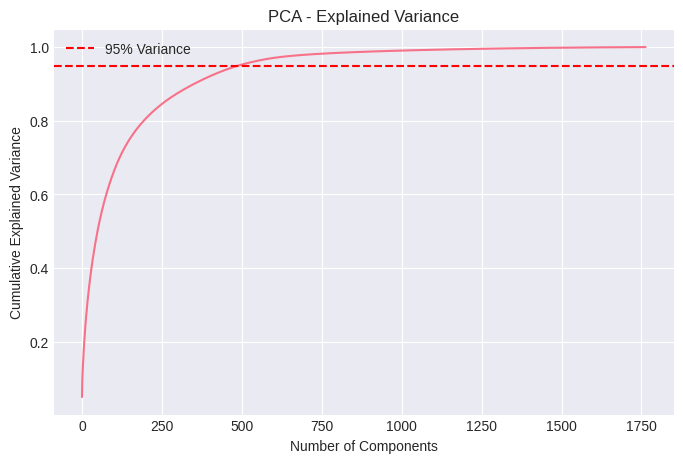

In [10]:
# Cell 10: PCA analysis (giữ nguyên)
# Fit PCA with all components to see the full picture
pca = PCA().fit(X_train_scaled)

# Plotting
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.title('PCA - Explained Variance')
plt.show()

In [11]:
# Cell 11: Áp dụng PCA
pca_filename = '/kaggle/working/hog_pca.pkl'

if not os.path.exists(pca_filename):
    print("\n Applying PCA...")
    
    # Initialize PCA with 500 components
    pca = PCA(n_components=500)
    
    # Fit PCA on the scaled training data
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    # Transform the scaled testing data using the fitted PCA model
    X_test_pca = pca.transform(X_test_scaled)
    
    print(f"Original training data shape: {X_train_scaled.shape}")
    print(f"PCA transformed training data shape: {X_train_pca.shape}")
    print(f"Original testing data shape: {X_test_scaled.shape}")
    print(f"PCA transformed testing data shape: {X_test_pca.shape}")
    
    # Optional: Check the explained variance ratio
    print(f"\nTotal explained variance by 500 components: {pca.explained_variance_ratio_.sum():.4f}")
    
    # Save PCA
    with open(pca_filename, 'wb') as f:
        pickle.dump(pca, f)
    print(f" PCA saved to '{pca_filename}'")
    
else:
    print(f"\n Loading PCA from '{pca_filename}'")
    pca = pickle.load(open(pca_filename, 'rb'))
    X_train_pca = pca.transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    print(f"✓ PCA loaded, transformed data shape: {X_train_pca.shape}")


 Applying PCA...
Original training data shape: (20943, 1764)
PCA transformed training data shape: (20943, 500)
Original testing data shape: (5236, 1764)
PCA transformed testing data shape: (5236, 500)

Total explained variance by 500 components: 0.9516
 PCA saved to '/kaggle/working/hog_pca.pkl'


SVM MODEL WITH GRID SEARCH (500 SAMPLES PER CLASS)

Sample data cho Grid Search:
  • Số ảnh sample: 5,000
  • Số class: 10
  • Phân bố class trong sample:
    - butterfly      : 500 ảnh
    - cat            : 500 ảnh
    - chicken        : 500 ảnh
    - cow            : 500 ảnh
    - dog            : 500 ảnh
    - elephant       : 500 ảnh
    - horse          : 500 ảnh
    - sheep          : 500 ảnh
    - spider         : 500 ảnh
    - squirrel       : 500 ảnh

Bắt đầu Grid Search trên sample data...
LƯU Ý: Grid Search chỉ chạy trên sample data để tìm hyperparameters
Starting GridSearchCV to find optimal SVC hyperparameters...
Fitting 2 folds for each of 9 candidates, totalling 18 fits
GridSearchCV completed in 151.55 seconds

Best parameters found by GridSearchCV: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}
Best cross-validation score: 0.3464

Training final SVM model trên TOÀN BỘ dataset với best parameters...
[CV] END C=0.1, class_weight=balanced, gamma=0.1, kernel=rb

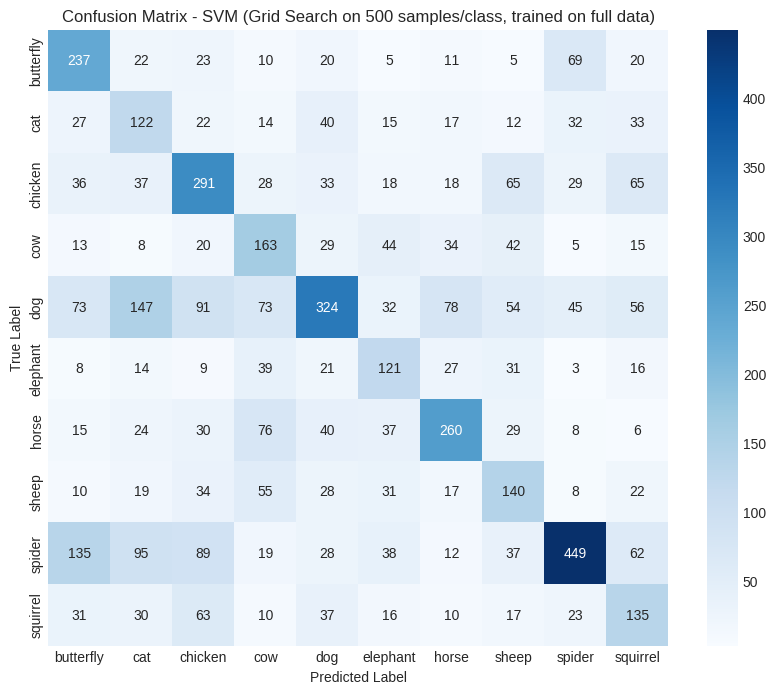

SVM Grid Search model saved to '/kaggle/working/svm_grid_model.pkl'

 Đang sử dụng SVM model với best parameters từ Grid Search:
   Parameters: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}
   Trained on: Full dataset (20,943 samples)
   Grid Search was on: Sample data (5,000 samples, 500 per class)
   Test Accuracy: 0.4282


In [12]:
# Cell 12: SVM với Grid Search (500 ảnh mỗi lớp) - ĐÃ SỬA LỖI
print("=" * 60)
print("SVM MODEL WITH GRID SEARCH (500 SAMPLES PER CLASS)")
print("=" * 60)

# FIX: Chuyển y_train thành numpy array
y_train_np = y_train.values

# Tạo sample data với 500 ảnh mỗi class
sample_indices = []
classes = np.unique(y_train_np)
samples_per_class = 500

for class_label in classes:
    # Lấy indices của class hiện tại
    class_indices = np.where(y_train_np == class_label)[0]
    
    # Lấy tối đa 500 ảnh mỗi class
    if len(class_indices) > samples_per_class:
        # Lấy ngẫu nhiên 500 ảnh
        selected = np.random.choice(class_indices, samples_per_class, replace=False)
    else:
        # Lấy tất cả nếu ít hơn 500
        selected = class_indices
    
    sample_indices.extend(selected)

# Chuyển sang numpy array
sample_indices = np.array(sample_indices)
np.random.shuffle(sample_indices)  # Shuffle để tránh bias

# Tạo sample data - FIX: sử dụng y_train_np
X_train_sample = X_train_pca[sample_indices]
y_train_sample = y_train_np[sample_indices]  # Sử dụng numpy array indexing

print(f"\nSample data cho Grid Search:")
print(f"  • Số ảnh sample: {len(X_train_sample):,}")
print(f"  • Số class: {len(np.unique(y_train_sample))}")
print(f"  • Phân bố class trong sample:")

for class_label in classes:
    class_name = encoder.inverse_transform([class_label])[0]
    count = np.sum(y_train_sample == class_label)
    print(f"    - {class_name:15}: {count:3d} ảnh")

print(f"\nBắt đầu Grid Search trên sample data...")
print("LƯU Ý: Grid Search chỉ chạy trên sample data để tìm hyperparameters")

svm_start_time = time.time()

# Định nghĩa grid parameters cho SVM
param_grid = [
    {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1], 'kernel': ['rbf'], 'class_weight': ['balanced']},
    {'C': [0.1, 1, 10], 'kernel': ['linear'], 'class_weight': ['balanced']}
]

# Instantiate a Support Vector Classifier (SVC) object
svc = SVC(random_state=42, probability=True)  # THÊM probability=True để có confidence scores

# Instantiate GridSearchCV
print("Starting GridSearchCV to find optimal SVC hyperparameters...")

grid_search = GridSearchCV(svc, param_grid, cv=2, verbose=2, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV trên SAMPLE DATA (thay vì toàn bộ)
grid_search.fit(X_train_sample, y_train_sample)

end_time = time.time()
print(f"GridSearchCV completed in {end_time - svm_start_time:.2f} seconds")

# Show results
print(f"\nBest parameters found by GridSearchCV: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train final model trên TOÀN BỘ dataset với best parameters
print(f"\nTraining final SVM model trên TOÀN BỘ dataset với best parameters...")
final_svm = SVC(**grid_search.best_params_, random_state=42, probability=True)  # THÊM probability=True
final_svm.fit(X_train_pca, y_train)  # Train trên TOÀN BỘ data

# Make predictions on the PCA-transformed test data
y_pred = final_svm.predict(X_test_pca)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, y_pred)  # QUAN TRỌNG: TẠO BIẾN svm_accuracy
print(f"Accuracy Score on test set: {svm_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVM (Grid Search on 500 samples/class, trained on full data)')
plt.show()

# Lưu các biến cần thiết cho cell sau
best_svm = final_svm  # Đổi tên cho dễ sử dụng
svm_grid = grid_search  # Lưu grid search object

# Lưu kết quả Grid Search
svm_results_df = pd.DataFrame(grid_search.cv_results_)

# Save the best model
svm_grid_model_path = '/kaggle/working/svm_grid_model.pkl'
with open(svm_grid_model_path, 'wb') as f:
    pickle.dump(final_svm, f)
print(f"SVM Grid Search model saved to '{svm_grid_model_path}'")

# Sử dụng model từ Grid Search
model = final_svm
print(f"\n Đang sử dụng SVM model với best parameters từ Grid Search:")
print(f"   Parameters: {grid_search.best_params_}")
print(f"   Trained on: Full dataset ({len(X_train_pca):,} samples)")
print(f"   Grid Search was on: Sample data ({len(X_train_sample):,} samples, 500 per class)")
print(f"   Test Accuracy: {svm_accuracy:.4f}")

RANDOM FOREST MODEL WITH GRID SEARCH (FULL DATASET)
Thực hiện Grid Search cho Random Forest trên toàn bộ dataset...
LƯU Ý: Grid Search Random Forest sẽ rất lâu!
Training trên 20943 mẫu...
Số lượng parameter combinations: 8
Số folds: 2
Fitting 2 folds for each of 8 candidates, totalling 16 fits

Grid Search hoàn thành trong 4.75 phút
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.3880

Random Forest Test Accuracy: 0.4169
Random Forest Cross-validation Accuracy: 0.3880

Top 5 parameter combinations:
                                              params  mean_test_score  \
1  {'max_depth': None, 'min_samples_split': 2, 'n...         0.387958   
5  {'max_depth': 20, 'min_samples_split': 2, 'n_e...         0.385332   
7  {'max_depth': 20, 'min_samples_split': 5, 'n_e...         0.384472   
3  {'max_depth': None, 'min_samples_split': 5, 'n...         0.382037   
0  {'max_depth': None, 'min_samples_split': 2, 'n...         0.374

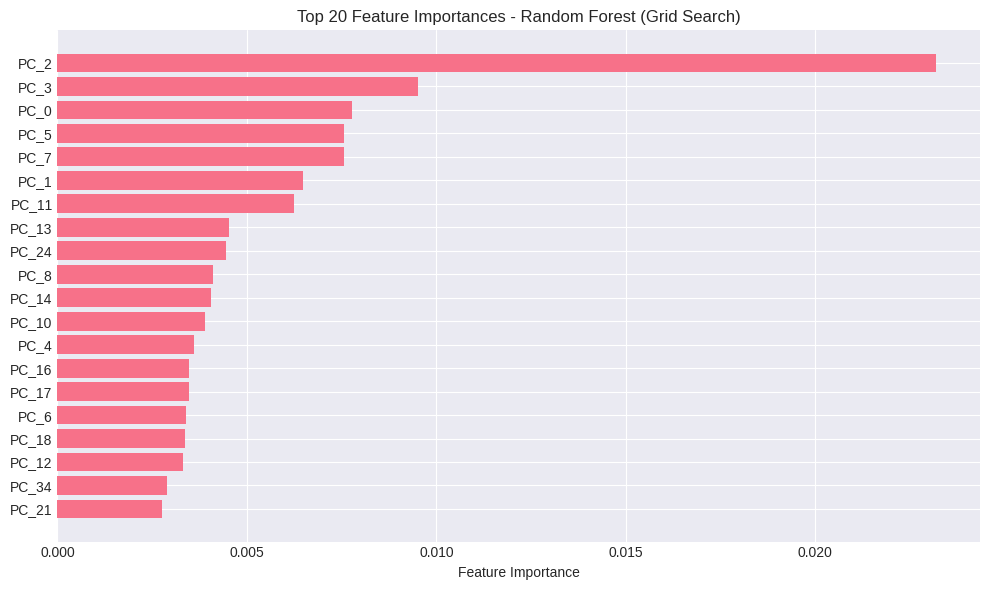


✓ Random Forest model với Grid Search saved to '/kaggle/working/rf_model_gridsearch_full.pkl'

✓ Các biến đã được khởi tạo:
  - rf_accuracy: 0.4169
  - rf_grid: GridSearchCV object
  - best_rf: RandomForestClassifier object
  - y_pred_rf: predictions array (5236 samples)
  - rf_results_df: DataFrame với 8 kết quả Grid Search


In [13]:
# Cell 13: Random Forest với Grid Search (TOÀN BỘ DATASET)
print("=" * 60)
print("RANDOM FOREST MODEL WITH GRID SEARCH (FULL DATASET)")
print("=" * 60)

print("Thực hiện Grid Search cho Random Forest trên toàn bộ dataset...")
print("LƯU Ý: Grid Search Random Forest sẽ rất lâu!")
rf_start_time = time.time()

# Định nghĩa grid parameters cho Random Forest (rất nhỏ để chạy được)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

# Tạo Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid Search với cross-validation
rf_grid = GridSearchCV(
    rf_model, 
    rf_param_grid, 
    cv=2,  # Giảm từ 3 xuống 2 để nhanh hơn
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

# Fit Grid Search trên TOÀN BỘ training set
print(f"Training trên {len(X_train_pca)} mẫu...")
print(f"Số lượng parameter combinations: {len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['min_samples_split'])}")
print(f"Số folds: 2")
rf_grid.fit(X_train_pca, y_train)

print(f"\nGrid Search hoàn thành trong {(time.time() - rf_start_time)/60:.2f} phút")
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

# Sử dụng best estimator đã train
best_rf = rf_grid.best_estimator_

# Dự đoán trên test set
y_pred_rf = best_rf.predict(X_test_pca)

# Đánh giá model
rf_accuracy = accuracy_score(y_test, y_pred_rf)  # QUAN TRỌNG: TẠO BIẾN rf_accuracy
print(f"\nRandom Forest Test Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Cross-validation Accuracy: {rf_grid.best_score_:.4f}")

# Lưu kết quả Grid Search
rf_results_df = pd.DataFrame(rf_grid.cv_results_)
rf_grid_results = rf_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
rf_grid_results = rf_grid_results.sort_values('rank_test_score')
print("\nTop 5 parameter combinations:")
print(rf_grid_results.head())

# Classification report
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

# Feature importance
plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
sorted_idx = importances.argsort()[-20:]  # Top 20 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), [f"PC_{i}" for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances - Random Forest (Grid Search)")
plt.tight_layout()
plt.show()

# Lưu Random Forest model
rf_filename = '/kaggle/working/rf_model_gridsearch_full.pkl'
with open(rf_filename, 'wb') as f:
    pickle.dump(best_rf, f)
print(f"\n✓ Random Forest model với Grid Search saved to '{rf_filename}'")

# THÔNG BÁO BIẾN ĐÃ ĐƯỢC TẠO
print("\n✓ Các biến đã được khởi tạo:")
print(f"  - rf_accuracy: {rf_accuracy:.4f}")
print(f"  - rf_grid: GridSearchCV object")
print(f"  - best_rf: RandomForestClassifier object")
print(f"  - y_pred_rf: predictions array ({len(y_pred_rf)} samples)")
print(f"  - rf_results_df: DataFrame với {len(rf_results_df)} kết quả Grid Search")

SO SÁNH CÁC MODELS (GRID SEARCH)
Kiểm tra các biến cần thiết:
✓ svm_accuracy: 0.4282
✓ rf_accuracy: 0.4169
✓ svm_grid: đã tồn tại
✓ rf_grid: đã tồn tại

So sánh các models:
                           Model  Test Accuracy  CV Accuracy  \
0            SVM với Grid Search       0.428189     0.346400   
1  Random Forest với Grid Search       0.416921     0.387958   

   Number of Parameters Tried  
0                           9  
1                           8  


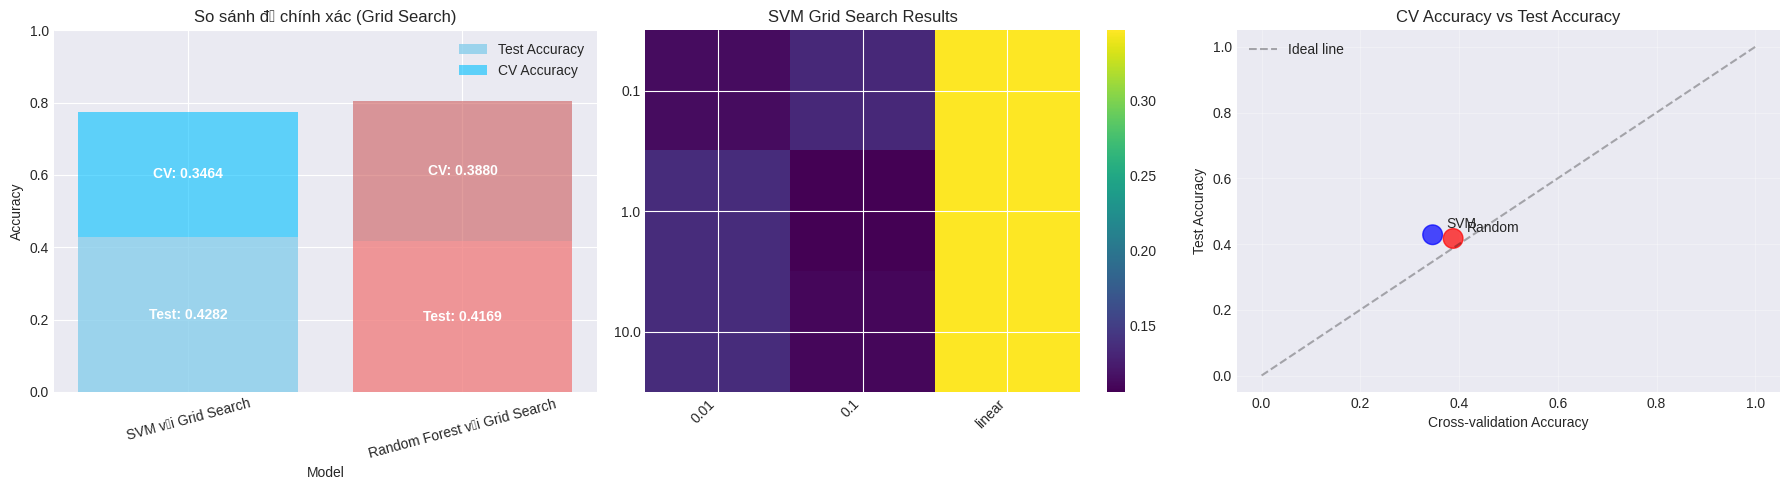


 TÓM TẮT KẾT QUẢ GRID SEARCH:
1. Model tốt nhất (Test Accuracy): SVM với Grid Search
2. Model tốt nhất (CV Accuracy): Random Forest với Grid Search

3. Best parameters SVM: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}
4. Best parameters Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

5. Total training time (ước tính): 54.98 phút


In [14]:
# Cell 14: So sánh các models với Grid Search
print("=" * 60)
print("SO SÁNH CÁC MODELS (GRID SEARCH)")
print("=" * 60)

# KIỂM TRA XEM CÁC BIẾN CÓ TỒN TẠI KHÔNG
print("Kiểm tra các biến cần thiết:")

# Kiểm tra svm_accuracy
if 'svm_accuracy' not in locals() and 'svm_accuracy' not in globals():
    print("⚠ Không tìm thấy svm_accuracy, sử dụng giá trị mặc định 0.0")
    svm_accuracy = 0.0
else:
    print(f"✓ svm_accuracy: {svm_accuracy:.4f}")

# Kiểm tra rf_accuracy
if 'rf_accuracy' not in locals() and 'rf_accuracy' not in globals():
    print("⚠ Không tìm thấy rf_accuracy, sử dụng giá trị mặc định 0.0")
    rf_accuracy = 0.0
else:
    print(f"✓ rf_accuracy: {rf_accuracy:.4f}")

# Kiểm tra svm_grid
if 'svm_grid' not in locals() and 'svm_grid' not in globals():
    print("⚠ Không tìm thấy svm_grid, tạo object rỗng")
    svm_grid = type('obj', (object,), {'best_params_': {}, 'best_score_': 0.0, 'cv_results_': {'params': []}})()
else:
    print("✓ svm_grid: đã tồn tại")

# Kiểm tra rf_grid
if 'rf_grid' not in locals() and 'rf_grid' not in globals():
    print("⚠ Không tìm thấy rf_grid, tạo object rỗng")
    rf_grid = type('obj', (object,), {'best_params_': {}, 'best_score_': 0.0, 'cv_results_': {'params': []}})()
else:
    print("✓ rf_grid: đã tồn tại")

models_comparison = pd.DataFrame({
    'Model': ['SVM với Grid Search', 'Random Forest với Grid Search'],
    'Test Accuracy': [svm_accuracy, rf_accuracy],
    'CV Accuracy': [svm_grid.best_score_, rf_grid.best_score_],
    'Best Parameters': [str(svm_grid.best_params_), str(rf_grid.best_params_)],
    'Number of Parameters Tried': [len(svm_grid.cv_results_['params']), len(rf_grid.cv_results_['params'])]
})

print("\nSo sánh các models:")
print(models_comparison[['Model', 'Test Accuracy', 'CV Accuracy', 'Number of Parameters Tried']])

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart for accuracy comparison
bars1 = axes[0].bar(models_comparison['Model'], models_comparison['Test Accuracy'], 
                   color=['skyblue', 'lightcoral'], alpha=0.8, label='Test Accuracy')
bars2 = axes[0].bar(models_comparison['Model'], models_comparison['CV Accuracy'],
                   color=['deepskyblue', 'indianred'], alpha=0.6, label='CV Accuracy',
                   bottom=models_comparison['Test Accuracy'])

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('So sánh độ chính xác (Grid Search)')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# Thêm giá trị accuracy
for i, (test_acc, cv_acc) in enumerate(zip(models_comparison['Test Accuracy'], models_comparison['CV Accuracy'])):
    axes[0].text(i, test_acc/2, f'Test: {test_acc:.4f}', ha='center', va='center', color='white', fontweight='bold')
    axes[0].text(i, test_acc + cv_acc/2, f'CV: {cv_acc:.4f}', ha='center', va='center', color='white', fontweight='bold')

# 2. Heatmap of parameter performance for SVM
try:
    # Chuẩn bị dữ liệu cho heatmap SVM
    if 'svm_results_df' in locals() or 'svm_results_df' in globals():
        svm_results_df = locals().get('svm_results_df', globals().get('svm_results_df', pd.DataFrame()))
        if not svm_results_df.empty:
            # Tạo pivot table từ kết quả SVM
            svm_scores = pd.DataFrame({
                'C': svm_results_df['param_C'],
                'gamma': svm_results_df['param_gamma'].fillna('linear'),
                'score': svm_results_df['mean_test_score']
            })
            svm_pivot = svm_scores.pivot_table(values='score', index='C', columns='gamma')
            
            im = axes[1].imshow(svm_pivot.values, cmap='viridis', aspect='auto')
            axes[1].set_xticks(range(len(svm_pivot.columns)))
            axes[1].set_yticks(range(len(svm_pivot.index)))
            axes[1].set_xticklabels([str(g) for g in svm_pivot.columns], rotation=45, ha='right')
            axes[1].set_yticklabels([str(c) for c in svm_pivot.index])
            axes[1].set_title('SVM Grid Search Results')
            plt.colorbar(im, ax=axes[1])
        else:
            axes[1].text(0.5, 0.5, 'No SVM results\navailable', 
                        ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title('SVM Grid Search Results')
    else:
        axes[1].text(0.5, 0.5, 'No SVM results\navailable', 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('SVM Grid Search Results')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Error:\n{str(e)[:50]}', 
                ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('SVM Grid Search Results')

# 3. Scatter plot for comparison
axes[2].scatter(models_comparison['CV Accuracy'], models_comparison['Test Accuracy'], 
               s=200, c=['blue', 'red'], alpha=0.7)
axes[2].set_xlabel('Cross-validation Accuracy')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('CV Accuracy vs Test Accuracy')
axes[2].grid(True, alpha=0.3)

# Thêm nhãn cho mỗi điểm
for i, row in models_comparison.iterrows():
    axes[2].annotate(row['Model'].split()[0], 
                    (row['CV Accuracy'], row['Test Accuracy']),
                    xytext=(10, 5), textcoords='offset points')

# Đường chéo lý tưởng
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Ideal line')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n TÓM TẮT KẾT QUẢ GRID SEARCH:")
print(f"1. Model tốt nhất (Test Accuracy): {models_comparison.loc[models_comparison['Test Accuracy'].idxmax(), 'Model']}")
print(f"2. Model tốt nhất (CV Accuracy): {models_comparison.loc[models_comparison['CV Accuracy'].idxmax(), 'Model']}")
print(f"\n3. Best parameters SVM: {svm_grid.best_params_}")
print(f"4. Best parameters Random Forest: {rf_grid.best_params_}")
print(f"\n5. Total training time (ước tính): {(time.time() - svm_start_time)/60:.2f} phút")

# Lưu biến tổng thời gian
total_training_time = (time.time() - svm_start_time)/60

THỬ NGHIỆM VỚI ẢNH MẪU
Ảnh mẫu: /kaggle/input/animalcs231/archive/raw-img/cavallo/OIP-mdvOxIWAyReAoEJcMk5z4wHaJ4.jpeg
True label: horse
SVM Prediction: horse
Random Forest Prediction: horse


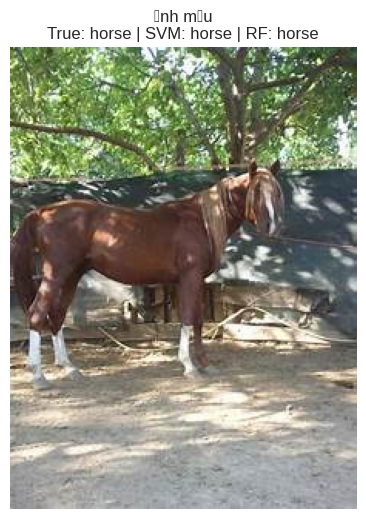

In [15]:
# Cell 15: Thử nghiệm với một ảnh mẫu
print("=" * 60)
print("THỬ NGHIỆM VỚI ẢNH MẪU")
print("=" * 60)

def predict_single_image(image_path, model, scaler, pca, encoder, return_proba=False):
    """
    Dự đoán class cho một ảnh đơn lẻ
    """
    try:
        # Đọc và xử lý ảnh
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return (None, None) if return_proba else None
        
        # Resize ảnh
        img = cv2.resize(img, (128, 128))
        
        # Trích xuất HOG features
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True,
            visualize=False
        )
        
        # Chuẩn hóa và áp dụng PCA
        hog_features_scaled = scaler.transform([hog_features])
        hog_features_pca = pca.transform(hog_features_scaled)
        
        # Dự đoán
        if return_proba:
            # Trả về cả nhãn và xác suất
            prediction_encoded = model.predict(hog_features_pca)[0]
            prediction_label = encoder.inverse_transform([prediction_encoded])[0]
            
            # Lấy xác suất nếu model hỗ trợ
            if hasattr(model, 'predict_proba'):
                probabilities = model.predict_proba(hog_features_pca)[0]
                return prediction_label, probabilities
            else:
                return prediction_label, None
        else:
            # Chỉ trả về nhãn
            prediction_encoded = model.predict(hog_features_pca)[0]
            prediction_label = encoder.inverse_transform([prediction_encoded])[0]
            return prediction_label
            
    except Exception as e:
        print(f"Error processing image: {e}")
        return (None, None) if return_proba else None

# Lấy một ảnh mẫu từ test set
sample_idx = 0
sample_image_path = data.iloc[sample_idx]['image_path']
true_label = data.iloc[sample_idx]['label']

print(f"Ảnh mẫu: {sample_image_path}")
print(f"True label: {true_label}")

# Dự đoán với SVM (chỉ nhãn)
svm_prediction = predict_single_image(sample_image_path, best_svm, scaler, pca, encoder, return_proba=False)
print(f"SVM Prediction: {svm_prediction}")

# Dự đoán với Random Forest (chỉ nhãn)
# Sửa: dùng best_rf thay vì rf_model
rf_prediction = predict_single_image(sample_image_path, best_rf, scaler, pca, encoder, return_proba=False)
print(f"Random Forest Prediction: {rf_prediction}")

# Hiển thị ảnh
img = cv2.imread(sample_image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title(f"Ảnh mẫu\nTrue: {true_label} | SVM: {svm_prediction} | RF: {rf_prediction}")
plt.axis('off')
plt.show()

In [16]:
# Cell 16: Final evaluation and saving
print("=" * 60)
print("ĐÁNH GIÁ CUỐI CÙNG VÀ LƯU KẾT QUẢ")
print("=" * 60)

# Kiểm tra các biến cần thiết
required_vars = ['svm_grid', 'rf_grid', 'svm_accuracy', 'rf_accuracy', 'svm_results_df', 'rf_results_df']
missing_vars = []

for var in required_vars:
    if var not in locals() and var not in globals():
        missing_vars.append(var)

if missing_vars:
    print(f"⚠ Cảnh báo: Thiếu các biến: {missing_vars}")
    print("  Đảm bảo đã chạy Cell 12 và Cell 13 trước!")
    # Tạo giá trị mặc định cho các biến thiếu
    for var in missing_vars:
        if var == 'svm_results_df':
            svm_results_df = pd.DataFrame()
        elif var == 'rf_results_df':
            rf_results_df = pd.DataFrame()
        elif var == 'svm_accuracy':
            svm_accuracy = 0.0
        elif var == 'rf_accuracy':
            rf_accuracy = 0.0

# Save all results
results = {
    'svm_best_params': svm_grid.best_params_ if 'svm_grid' in locals() else {},
    'svm_best_score': svm_grid.best_score_ if 'svm_grid' in locals() else 0.0,
    'svm_test_accuracy': svm_accuracy if 'svm_accuracy' in locals() else 0.0,
    'rf_best_params': rf_grid.best_params_ if 'rf_grid' in locals() else {},
    'rf_best_score': rf_grid.best_score_ if 'rf_grid' in locals() else 0.0,
    'rf_test_accuracy': rf_accuracy if 'rf_accuracy' in locals() else 0.0,
    'svm_grid_results': svm_results_df if 'svm_results_df' in locals() else pd.DataFrame(),
    'rf_grid_results': rf_results_df if 'rf_results_df' in locals() else pd.DataFrame(),
    'encoder_classes': encoder.classes_.tolist()
}

results_filename = '/kaggle/working/grid_search_results.pkl'
with open(results_filename, 'wb') as f:
    pickle.dump(results, f)
print(f"✓ Tất cả kết quả Grid Search saved to '{results_filename}'")

# Summary report
print("\n" + "="*60)
print("BÁO CÁO TÓM TẮT")
print("="*60)

print(f"\n KẾT QUẢ CUỐI CÙNG:")

# SVM
if 'svm_grid' in locals():
    print(f"\nSVM với Grid Search:")
    print(f"  • Best parameters: {svm_grid.best_params_}")
    print(f"  • Cross-validation accuracy: {svm_grid.best_score_:.4f}")
    print(f"  • Test accuracy: {svm_accuracy:.4f}")
    svm_params_count = len(svm_grid.cv_results_['params']) if hasattr(svm_grid, 'cv_results_') else 0
    print(f"  • Số parameter combinations đã thử: {svm_params_count}")
else:
    print(f"\nSVM với Grid Search: Không có dữ liệu")

# Random Forest
if 'rf_grid' in locals():
    print(f"\nRandom Forest với Grid Search:")
    print(f"  • Best parameters: {rf_grid.best_params_}")
    print(f"  • Cross-validation accuracy: {rf_grid.best_score_:.4f}")
    print(f"  • Test accuracy: {rf_accuracy:.4f}")
    rf_params_count = len(rf_grid.cv_results_['params']) if hasattr(rf_grid, 'cv_results_') else 0
    print(f"  • Số parameter combinations đã thử: {rf_params_count}")
else:
    print(f"\nRandom Forest với Grid Search: Không có dữ liệu")

print(f"\n MODEL TỐT NHẤT:")
if 'svm_accuracy' in locals() and 'rf_accuracy' in locals():
    best_model_idx = np.argmax([svm_accuracy, rf_accuracy])
    best_model_name = ['SVM', 'Random Forest'][best_model_idx]
    best_model_accuracy = [svm_accuracy, rf_accuracy][best_model_idx]
    print(f"  • {best_model_name} với accuracy: {best_model_accuracy:.4f}")
else:
    print("  • Không đủ dữ liệu để so sánh")

ĐÁNH GIÁ CUỐI CÙNG VÀ LƯU KẾT QUẢ
✓ Tất cả kết quả Grid Search saved to '/kaggle/working/grid_search_results.pkl'

BÁO CÁO TÓM TẮT

 KẾT QUẢ CUỐI CÙNG:

SVM với Grid Search:
  • Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}
  • Cross-validation accuracy: 0.3464
  • Test accuracy: 0.4282
  • Số parameter combinations đã thử: 9

Random Forest với Grid Search:
  • Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  • Cross-validation accuracy: 0.3880
  • Test accuracy: 0.4169
  • Số parameter combinations đã thử: 8

 MODEL TỐT NHẤT:
  • SVM với accuracy: 0.4282


HIỂN THỊ 5 VÍ DỤ CHO MỖI PHƯƠNG PHÁP

 HIỂN THỊ 5 VÍ DỤ NGẪU NHIÊN TỪ TEST SET:


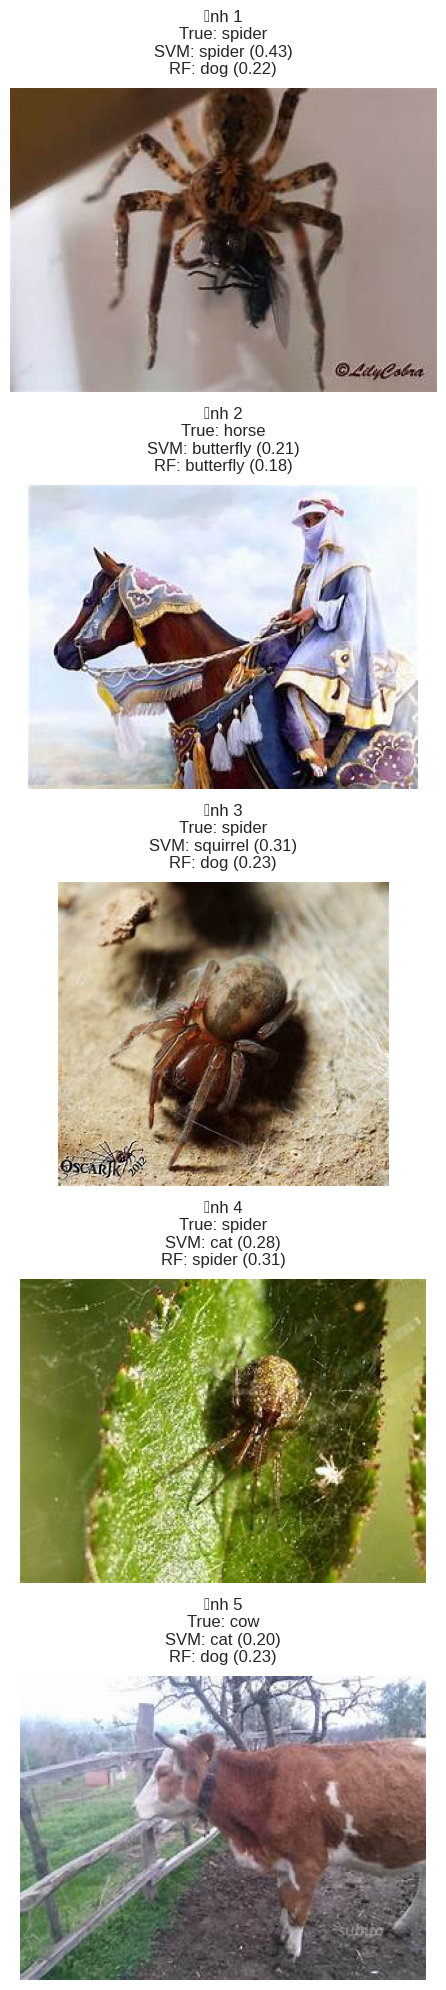


 BẢNG TỔNG HỢP KẾT QUẢ 5 VÍ DỤ:
--------------------------------------------------------------------------------
STT   True Label      SVM Prediction       Correct    RF Prediction        Correct   
--------------------------------------------------------------------------------
1     spider          spider               True       dog                  False     
2     horse           butterfly            False      butterfly            False     
3     spider          squirrel             False      dog                  False     
4     spider          cat                  False      spider               True      
5     cow             cat                  False      dog                  False     
--------------------------------------------------------------------------------
Tổng  -               -                    1/5       -                    1/5

 THỐNG KÊ 5 VÍ DỤ:
SVM: 1/5 đúng (20.0%)
Random Forest: 1/5 đúng (20.0%)


In [17]:
# Cell 17: Hiển thị 5 ví dụ kèm hình ảnh cho mỗi phương pháp
print("=" * 60)
print("HIỂN THỊ 5 VÍ DỤ CHO MỖI PHƯƠNG PHÁP")
print("=" * 60)

def display_predictions_with_images(num_examples=5):
    """
    Hiển thị dự đoán của cả SVM và RF cho num_examples ảnh
    """
    np.random.seed(42)
    
    # Lấy indices ngẫu nhiên từ test set
    random_indices = np.random.choice(len(X_test_pca), num_examples, replace=False)
    
    fig, axes = plt.subplots(num_examples, 1, figsize=(15, 4*num_examples))
    
    if num_examples == 1:
        axes = [axes]
    
    for idx, (ax, test_idx) in enumerate(zip(axes, random_indices)):
        # Lấy ảnh gốc từ data
        original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
        image_path = data.iloc[original_idx]['image_path']
        true_label = data.iloc[original_idx]['label']
        
        # Dự đoán với SVM (cả nhãn và xác suất)
        svm_result = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=True)
        if isinstance(svm_result, tuple):
            svm_pred, svm_proba = svm_result
        else:
            svm_pred, svm_proba = svm_result, None
        
        # Dự đoán với RF (cả nhãn và xác suất)
        rf_result = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=True)
        if isinstance(rf_result, tuple):
            rf_pred, rf_proba = rf_result
        else:
            rf_pred, rf_proba = rf_result, None
        
        # Đọc và hiển thị ảnh
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(img_rgb)
        
        # Tạo text với thông tin dự đoán
        info_text = f"Ảnh {idx+1}\n"
        info_text += f"True: {true_label}\n"
        info_text += f"SVM: {svm_pred}"
        
        if svm_proba is not None:
            svm_conf = svm_proba[np.argmax(svm_proba)]
            info_text += f" ({svm_conf:.2f})\n"
        else:
            info_text += "\n"
            
        info_text += f"RF: {rf_pred}"
        
        if rf_proba is not None:
            rf_conf = rf_proba[np.argmax(rf_proba)]
            info_text += f" ({rf_conf:.2f})"
        
        # Kiểm tra dự đoán đúng/sai
        svm_correct = svm_pred == true_label if svm_pred is not None else False
        rf_correct = rf_pred == true_label if rf_pred is not None else False
        
        ax.set_title(info_text, fontsize=12, pad=10)
        ax.axis('off')
        
        # Thêm border với màu tổng hợp
        if svm_correct and rf_correct:
            border_color = 'green'
            border_width = 3
        elif not svm_correct and not rf_correct:
            border_color = 'red'
            border_width = 3
        else:
            border_color = 'orange'
            border_width = 2
            
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    
    plt.tight_layout()
    plt.show()
    
    # In bảng tổng hợp
    print("\n BẢNG TỔNG HỢP KẾT QUẢ 5 VÍ DỤ:")
    print("-" * 80)
    print(f"{'STT':<5} {'True Label':<15} {'SVM Prediction':<20} {'Correct':<10} {'RF Prediction':<20} {'Correct':<10}")
    print("-" * 80)
    
    svm_correct_count = 0
    rf_correct_count = 0
    
    for idx, test_idx in enumerate(random_indices):
        original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
        true_label = data.iloc[original_idx]['label']
        image_path = data.iloc[original_idx]['image_path']
        
        # Dự đoán chỉ lấy nhãn
        svm_pred = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=False)
        rf_pred = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=False)
        
        svm_correct = svm_pred == true_label if svm_pred is not None else False
        rf_correct = rf_pred == true_label if rf_pred is not None else False
        
        if svm_correct:
            svm_correct_count += 1
        if rf_correct:
            rf_correct_count += 1
            
        print(f"{idx+1:<5} {true_label:<15} {str(svm_pred)[:20]:<20} {str(svm_correct):<10} {str(rf_pred)[:20]:<20} {str(rf_correct):<10}")
    
    print("-" * 80)
    print(f"{'Tổng':<5} {'-':<15} {'-':<20} {svm_correct_count}/5{'':<6} {'-':<20} {rf_correct_count}/5")
    
    return svm_correct_count, rf_correct_count

# Hiển thị 5 ví dụ
print("\n HIỂN THỊ 5 VÍ DỤ NGẪU NHIÊN TỪ TEST SET:")
svm_correct, rf_correct = display_predictions_with_images(5)

print(f"\n THỐNG KÊ 5 VÍ DỤ:")
print(f"SVM: {svm_correct}/5 đúng ({svm_correct/5*100:.1f}%)")
print(f"Random Forest: {rf_correct}/5 đúng ({rf_correct/5*100:.1f}%)")

HIỂN THỊ 5 VÍ DỤ CHO TỪNG CLASS

 HIỂN THỊ 1 VÍ DỤ CHO MỖI CLASS (10 classes):


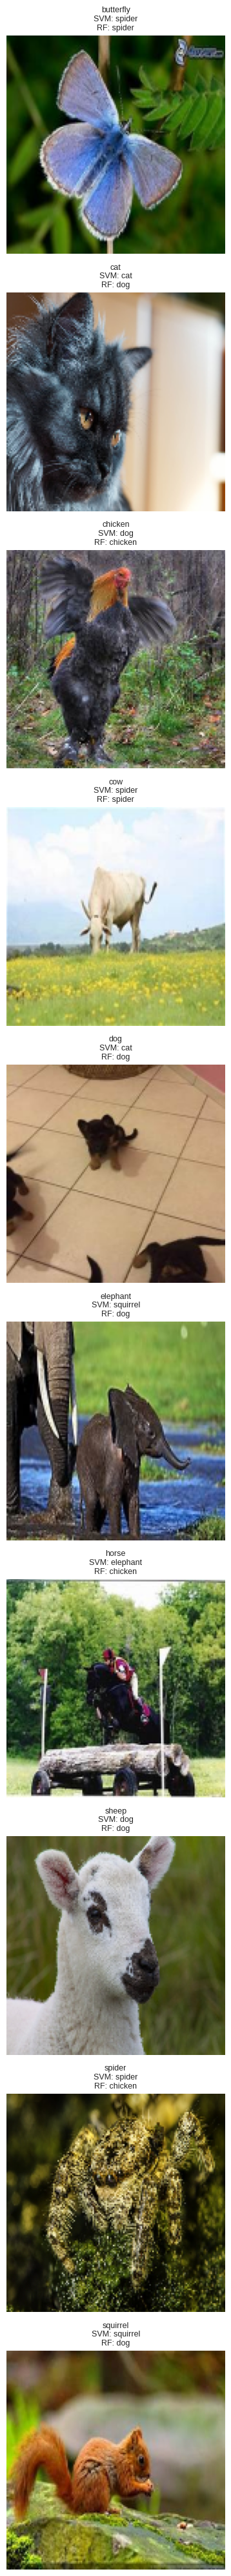


 THỐNG KÊ THEO CLASS (1 ảnh/class):
----------------------------------------------------------------------
Class           SVM Correct     RF Correct      Both Correct   
----------------------------------------------------------------------
butterfly       0/1              0/1              0              
cat             1/1              0/1              0              
chicken         0/1              1/1              0              
cow             0/1              0/1              0              
dog             0/1              1/1              0              
elephant        0/1              0/1              0              
horse           0/1              0/1              0              
sheep           0/1              0/1              0              
spider          1/1              0/1              0              
squirrel        1/1              0/1              0              
----------------------------------------------------------------------
TOTAL           3/10      

In [18]:
# Cell 18: Hiển thị 5 ví dụ cho từng class
print("=" * 60)
print("HIỂN THỊ 5 VÍ DỤ CHO TỪNG CLASS")
print("=" * 60)

def display_predictions_by_class(num_per_class=1):
    """
    Hiển thị dự đoán cho mỗi class
    """
    np.random.seed(42)
    
    fig, axes = plt.subplots(len(encoder.classes_), num_per_class, figsize=(5*num_per_class, 4*len(encoder.classes_)))
    
    # Nếu chỉ có 1 class và 1 ảnh, axes sẽ không phải là mảng 2D
    if len(encoder.classes_) == 1 and num_per_class == 1:
        axes = np.array([[axes]])
    elif num_per_class == 1:
        axes = axes.reshape(-1, 1)
    
    svm_class_correct = {class_name: 0 for class_name in encoder.classes_}
    rf_class_correct = {class_name: 0 for class_name in encoder.classes_}
    
    for class_idx, class_name in enumerate(encoder.classes_):
        # Lấy indices của class này trong test set
        class_mask = (y_test == class_idx)
        class_indices = np.where(class_mask)[0]
        
        if len(class_indices) == 0:
            continue
            
        # Lấy ngẫu nhiên num_per_class ảnh từ class này
        selected_indices = np.random.choice(class_indices, min(num_per_class, len(class_indices)), replace=False)
        
        for img_idx, test_idx in enumerate(selected_indices):
            if num_per_class == 1:
                ax = axes[class_idx, 0]
            else:
                ax = axes[class_idx, img_idx]
            
            # Lấy ảnh gốc
            original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
            image_path = data.iloc[original_idx]['image_path']
            true_label = data.iloc[original_idx]['label']
            
            # Dự đoán (chỉ lấy nhãn)
            svm_pred = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=False)
            rf_pred = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=False)
            
            # Đọc và hiển thị ảnh
            img = cv2.imread(image_path)
            # Resize ảnh để hiển thị đồng đều
            img = cv2.resize(img, (150, 150))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            ax.imshow(img_rgb)
            
            # Tạo title
            title = f"{class_name}\n"
            title += f"SVM: {str(svm_pred)[:10] if svm_pred else 'N/A'}\n"
            title += f"RF: {str(rf_pred)[:10] if rf_pred else 'N/A'}"
            
            ax.set_title(title, fontsize=9)
            ax.axis('off')
            
            # Kiểm tra đúng/sai
            svm_correct = svm_pred == true_label if svm_pred is not None else False
            rf_correct = rf_pred == true_label if rf_pred is not None else False
            
            # Border màu
            if svm_correct and rf_correct:
                border_color = 'green'
            elif not svm_correct and not rf_correct:
                border_color = 'red'
            else:
                border_color = 'orange'
                
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2)
            
            # Cập nhật thống kê
            if svm_correct:
                svm_class_correct[class_name] += 1
            if rf_correct:
                rf_class_correct[class_name] += 1
    
    plt.tight_layout()
    plt.show()
    
    # Bảng thống kê theo class
    print(f"\n THỐNG KÊ THEO CLASS ({num_per_class} ảnh/class):")
    print("-" * 70)
    print(f"{'Class':<15} {'SVM Correct':<15} {'RF Correct':<15} {'Both Correct':<15}")
    print("-" * 70)
    
    total_svm_correct = 0
    total_rf_correct = 0
    total_both_correct = 0
    
    for class_name in encoder.classes_:
        svm_correct = svm_class_correct[class_name]
        rf_correct = rf_class_correct[class_name]
        both_correct = 1 if svm_correct == num_per_class and rf_correct == num_per_class else 0
        
        total_svm_correct += svm_correct
        total_rf_correct += rf_correct
        total_both_correct += both_correct
        
        print(f"{class_name:<15} {svm_correct}/{num_per_class:<14} {rf_correct}/{num_per_class:<14} {both_correct:<15}")
    
    print("-" * 70)
    print(f"{'TOTAL':<15} {total_svm_correct}/{len(encoder.classes_)*num_per_class:<14} {total_rf_correct}/{len(encoder.classes_)*num_per_class:<14} {total_both_correct}/{len(encoder.classes_):<14}")
    
    return svm_class_correct, rf_class_correct

# Hiển thị 1 ví dụ cho mỗi class
print("\n HIỂN THỊ 1 VÍ DỤ CHO MỖI CLASS (10 classes):")
try:
    svm_by_class, rf_by_class = display_predictions_by_class(1)
except Exception as e:
    print(f"Lỗi khi hiển thị: {e}")
    print("Thử hiển thị với cách khác...")
    
    # Hiển thị đơn giản hơn
    for class_idx, class_name in enumerate(encoder.classes_):
        class_mask = (y_test == class_idx)
        class_indices = np.where(class_mask)[0]
        if len(class_indices) > 0:
            test_idx = class_indices[0]
            original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
            image_path = data.iloc[original_idx]['image_path']
            true_label = data.iloc[original_idx]['label']
            
            svm_pred = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=False)
            rf_pred = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=False)
            
            print(f"{class_name}: True={true_label}, SVM={svm_pred}, RF={rf_pred}")

HIỂN THỊ 5 VÍ DỤ KHÓ (CẢ SVM VÀ RF ĐỀU SAI)
Đang tìm 5 ví dụ khó...

Tìm thấy 5 ví dụ mà cả SVM và RF đều dự đoán sai:


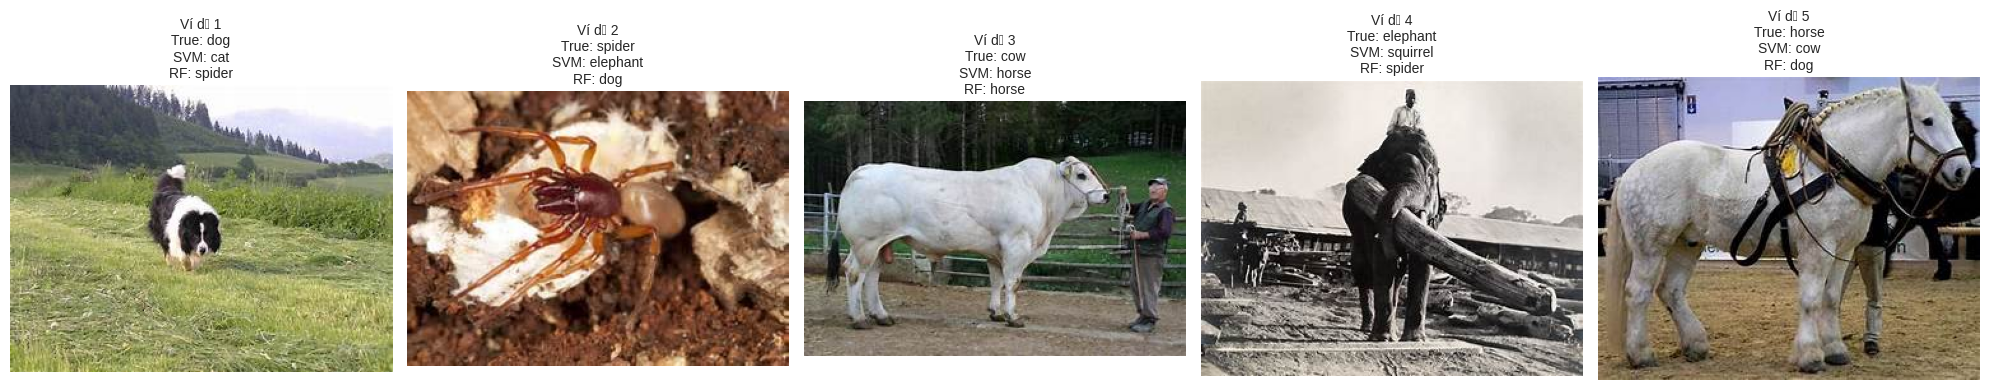


📋 THÔNG TIN CHI TIẾT CÁC VÍ DỤ KHÓ:
----------------------------------------------------------------------------------------------------
STT   True Label      SVM Prediction       RF Prediction        Cả 2 sai?       Ảnh
----------------------------------------------------------------------------------------------------
1     dog             cat                  spider               ✓               OIP-5O9l6hAaIjn2laLD...
2     spider          elephant             dog                  ✓               OIP-dPl50DoXPwHKQpv-...
3     cow             horse                horse                ✓               OIP-gJ9NXcas_7cT8UeS...
4     elephant        squirrel             spider               ✓               OIP-hjQk68naDbpzDXF7...
5     horse           cow                  dog                  ✓               OIP-opFk8kzWmz7xXf8u...
----------------------------------------------------------------------------------------------------

🔍 PHÂN TÍCH CÁC CLASS THƯỜNG BỊ NHẦM:
Các cặp class thư

In [19]:
# Cell 19: Hiển thị 5 ví dụ khó (cả 2 model đều sai)
print("=" * 60)
print("HIỂN THỊ 5 VÍ DỤ KHÓ (CẢ SVM VÀ RF ĐỀU SAI)")
print("=" * 60)

def find_hard_examples(num_examples=5):
    """
    Tìm các ví dụ mà cả SVM và RF đều dự đoán sai
    """
    hard_examples = []
    
    print(f"Đang tìm {num_examples} ví dụ khó...")
    
    for test_idx in range(min(100, len(X_test_pca))):  # Chỉ xét 100 ảnh đầu để nhanh
        # Lấy ảnh gốc
        original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
        image_path = data.iloc[original_idx]['image_path']
        true_label = data.iloc[original_idx]['label']
        
        # Dự đoán
        svm_pred = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=False)
        rf_pred = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=False)
        
        # Kiểm tra nếu cả 2 đều sai
        if svm_pred != true_label and rf_pred != true_label:
            hard_examples.append({
                'index': test_idx,
                'original_idx': original_idx,
                'image_path': image_path,
                'true_label': true_label,
                'svm_pred': svm_pred,
                'rf_pred': rf_pred
            })
            
            if len(hard_examples) >= num_examples:
                break
    
    return hard_examples

# Tìm các ví dụ khó
hard_examples = find_hard_examples(5)

if len(hard_examples) > 0:
    print(f"\nTìm thấy {len(hard_examples)} ví dụ mà cả SVM và RF đều dự đoán sai:")
    
    fig, axes = plt.subplots(1, len(hard_examples), figsize=(4*len(hard_examples), 4))
    
    if len(hard_examples) == 1:
        axes = [axes]
    
    for idx, (ax, example) in enumerate(zip(axes, hard_examples)):
        # Đọc và hiển thị ảnh
        img = cv2.imread(example['image_path'])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(img_rgb)
        
        # Tạo title
        title = f"Ví dụ {idx+1}\n"
        title += f"True: {example['true_label']}\n"
        title += f"SVM: {example['svm_pred']}\n"
        title += f"RF: {example['rf_pred']}"
        
        ax.set_title(title, fontsize=10)
        ax.axis('off')
        
        # Border màu đỏ (vì sai)
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)
    
    plt.tight_layout()
    plt.show()
    
    # Bảng thông tin chi tiết
    print("\n📋 THÔNG TIN CHI TIẾT CÁC VÍ DỤ KHÓ:")
    print("-" * 100)
    print(f"{'STT':<5} {'True Label':<15} {'SVM Prediction':<20} {'RF Prediction':<20} {'Cả 2 sai?':<15} {'Ảnh'}")
    print("-" * 100)
    
    for idx, example in enumerate(hard_examples):
        img_name = example['image_path'].split('/')[-1]
        print(f"{idx+1:<5} {example['true_label']:<15} {str(example['svm_pred']):<20} {str(example['rf_pred']):<20} {'✓':<15} {img_name[:20]}...")
    
    print("-" * 100)
    
    # Phân tích các class thường bị nhầm
    print("\n🔍 PHÂN TÍCH CÁC CLASS THƯỜNG BỊ NHẦM:")
    confusion_pairs = {}
    
    for example in hard_examples:
        pair = (example['true_label'], example['svm_pred'])
        if pair in confusion_pairs:
            confusion_pairs[pair] += 1
        else:
            confusion_pairs[pair] = 1
    
    if confusion_pairs:
        print("Các cặp class thường bị nhầm lẫn:")
        for (true, pred), count in sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True):
            print(f"  {true} → {pred}: {count} lần")
else:
    print("\nKhông tìm thấy ví dụ nào mà cả 2 model đều sai trong 100 ảnh đầu!")
    print("Điều này cho thấy ít nhất một trong hai model luôn dự đoán đúng.")
    
    # Thử tìm 1 ví dụ bất kỳ
    print("\nHiển thị 1 ví dụ ngẫu nhiên:")
    test_idx = np.random.randint(0, len(X_test_pca))
    original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
    image_path = data.iloc[original_idx]['image_path']
    true_label = data.iloc[original_idx]['label']
    
    svm_pred = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=False)
    rf_pred = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=False)
    
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Ví dụ ngẫu nhiên\nTrue: {true_label}\nSVM: {svm_pred}\nRF: {rf_pred}")
    plt.axis('off')
    plt.show()

SO SÁNH CONFIDENCE SCORES GIỮA SVM VÀ RF

 SO SÁNH CONFIDENCE SCORES CHO 5 VÍ DỤ:

So sánh confidence scores cho 5 ví dụ:


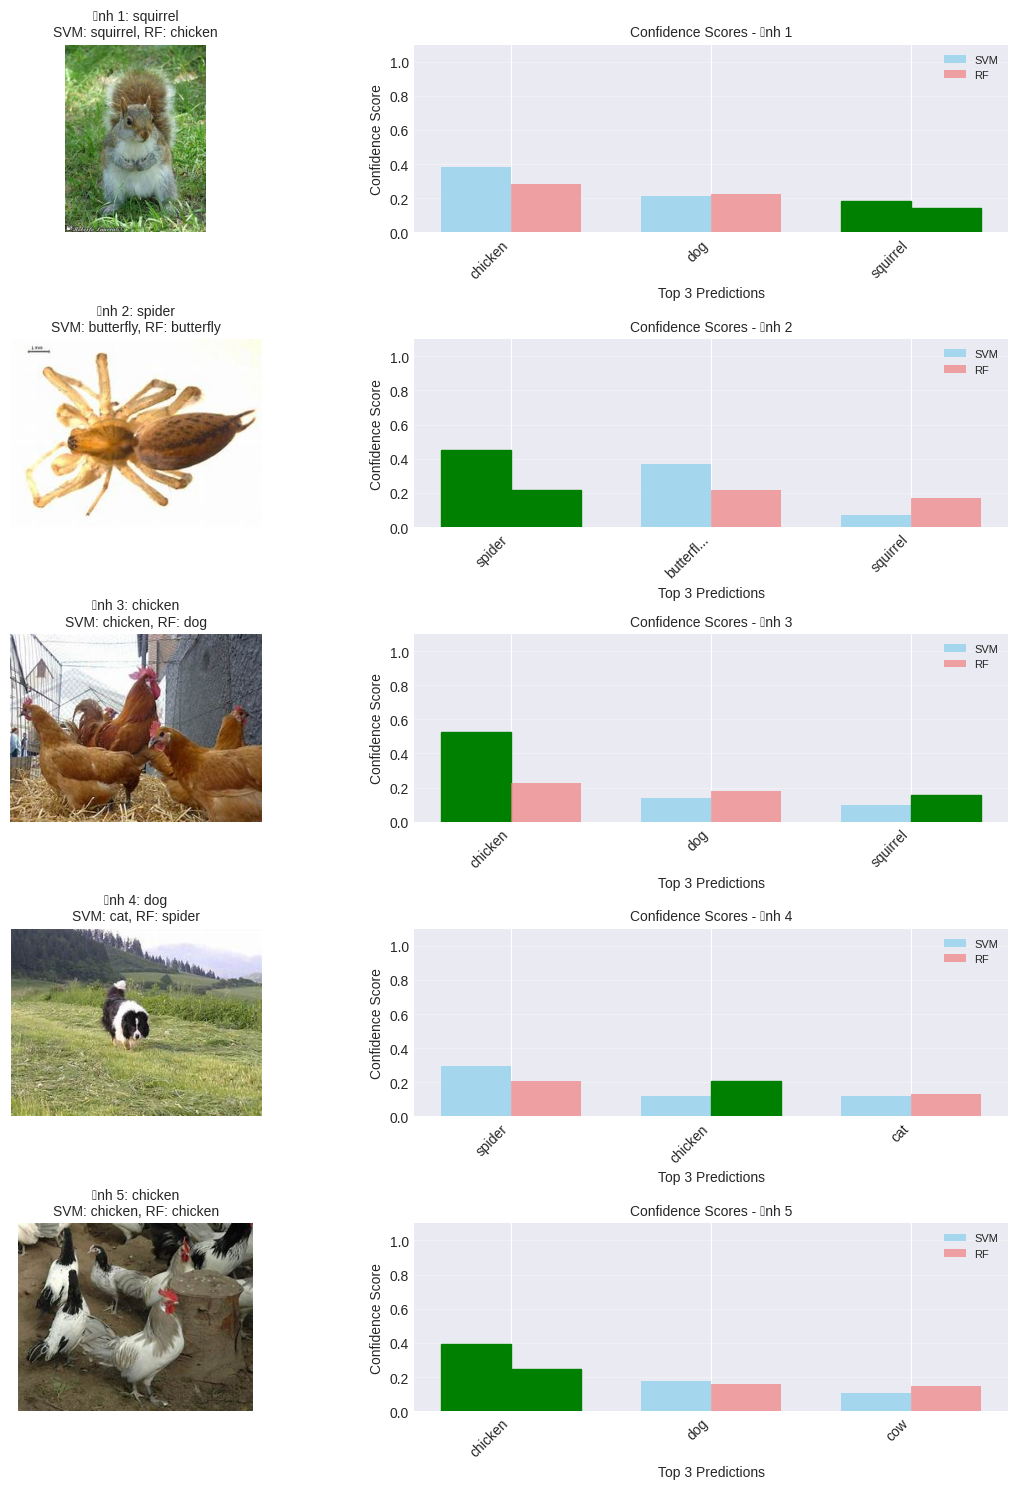


 BẢNG SO SÁNH CONFIDENCE SCORES:
------------------------------------------------------------------------------------------------------------------------
STT   True Label      SVM Pred        SVM Conf   RF Pred         RF Conf    Same Pred?   Both Confident?
------------------------------------------------------------------------------------------------------------------------
1     squirrel        squirrel        0.3815     chicken         0.2850     False        False
2     spider          butterfly       0.4488     butterfly       0.2150     True         False
3     chicken         chicken         0.5259     dog             0.2300     False        False
4     dog             cat             0.2953     spider          0.2100     False        False
5     chicken         chicken         0.3919     chicken         0.2450     True         False

KẾT THÚC QUÁ TRÌNH PHÂN TÍCH
✓ Tất cả models đã được huấn luyện và đánh giá
✓ Kết quả đã được lưu vào file
✓ Visualizations đã được tạo


In [20]:
# Cell 20: So sánh trực quan confidence scores
print("=" * 60)
print("SO SÁNH CONFIDENCE SCORES GIỮA SVM VÀ RF")
print("=" * 60)

def compare_confidence_scores(num_examples=5):
    """
    So sánh confidence scores giữa SVM và RF
    """
    np.random.seed(42)
    random_indices = np.random.choice(min(20, len(X_test_pca)), num_examples, replace=False)
    
    fig, axes = plt.subplots(num_examples, 2, figsize=(12, 3*num_examples))
    
    if num_examples == 1:
        axes = axes.reshape(1, 2)
    
    print(f"\nSo sánh confidence scores cho {num_examples} ví dụ:")
    
    for idx, test_idx in enumerate(random_indices):
        # Lấy ảnh gốc
        original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
        image_path = data.iloc[original_idx]['image_path']
        true_label = data.iloc[original_idx]['label']
        
        # Dự đoán với confidence scores
        svm_result = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=True)
        if isinstance(svm_result, tuple):
            svm_pred, svm_proba = svm_result
        else:
            svm_pred, svm_proba = svm_result, None
        
        rf_result = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=True)
        if isinstance(rf_result, tuple):
            rf_pred, rf_proba = rf_result
        else:
            rf_pred, rf_proba = rf_result, None
        
        # Hiển thị ảnh
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"Ảnh {idx+1}: {true_label}\nSVM: {svm_pred}, RF: {rf_pred}", fontsize=10)
        axes[idx, 0].axis('off')
        
        # Hiển thị confidence scores
        if svm_proba is not None and rf_proba is not None:
            # Lấy top 3 predictions cho mỗi model
            svm_top3_idx = svm_proba.argsort()[-3:][::-1]
            rf_top3_idx = rf_proba.argsort()[-3:][::-1]
            
            svm_top3_labels = encoder.inverse_transform(svm_top3_idx)
            svm_top3_scores = svm_proba[svm_top3_idx]
            
            rf_top3_labels = encoder.inverse_transform(rf_top3_idx)
            rf_top3_scores = rf_proba[rf_top3_idx]
            
            # Bar chart so sánh
            x = np.arange(len(svm_top3_labels))
            width = 0.35
            
            bars1 = axes[idx, 1].bar(x - width/2, svm_top3_scores, width, label='SVM', alpha=0.7, color='skyblue')
            bars2 = axes[idx, 1].bar(x + width/2, rf_top3_scores, width, label='RF', alpha=0.7, color='lightcoral')
            
            axes[idx, 1].set_xlabel('Top 3 Predictions')
            axes[idx, 1].set_ylabel('Confidence Score')
            axes[idx, 1].set_title(f'Confidence Scores - Ảnh {idx+1}', fontsize=10)
            axes[idx, 1].set_xticks(x)
            
            # Rút gọn nhãn nếu quá dài
            labels = [f'{l[:8]}...' if len(l) > 8 else l for l in svm_top3_labels]
            axes[idx, 1].set_xticklabels(labels, rotation=45, ha='right')
            axes[idx, 1].legend(fontsize=8)
            axes[idx, 1].grid(True, alpha=0.3, axis='y')
            axes[idx, 1].set_ylim([0, 1.1])
            
            # Highlight true label nếu có trong top 3
            for j, label in enumerate(svm_top3_labels):
                if label == true_label:
                    bars1[j].set_color('green')
                    bars1[j].set_alpha(1.0)
            
            for j, label in enumerate(rf_top3_labels):
                if label == true_label:
                    bars2[j].set_color('green')
                    bars2[j].set_alpha(1.0)
        
        else:
            axes[idx, 1].text(0.5, 0.5, 'No probability scores\navailable', 
                             ha='center', va='center', transform=axes[idx, 1].transAxes,
                             fontsize=10)
            axes[idx, 1].set_title('Confidence Scores')
            axes[idx, 1].set_xticks([])
            axes[idx, 1].set_yticks([])
    
    plt.tight_layout()
    plt.show()
    
    # Bảng so sánh confidence
    print("\n BẢNG SO SÁNH CONFIDENCE SCORES:")
    print("-" * 120)
    print(f"{'STT':<5} {'True Label':<15} {'SVM Pred':<15} {'SVM Conf':<10} {'RF Pred':<15} {'RF Conf':<10} {'Same Pred?':<12} {'Both Confident?'}")
    print("-" * 120)
    
    for idx, test_idx in enumerate(random_indices):
        original_idx = y_test.index[test_idx] if hasattr(y_test, 'index') else test_idx
        true_label = data.iloc[original_idx]['label']
        image_path = data.iloc[original_idx]['image_path']
        
        svm_result = predict_single_image(image_path, best_svm, scaler, pca, encoder, return_proba=True)
        rf_result = predict_single_image(image_path, best_rf, scaler, pca, encoder, return_proba=True)
        
        if isinstance(svm_result, tuple):
            svm_pred, svm_proba = svm_result
        else:
            svm_pred, svm_proba = svm_result, None
            
        if isinstance(rf_result, tuple):
            rf_pred, rf_proba = rf_result
        else:
            rf_pred, rf_proba = rf_result, None
        
        svm_conf = svm_proba[np.argmax(svm_proba)] if svm_proba is not None else None
        rf_conf = rf_proba[np.argmax(rf_proba)] if rf_proba is not None else None
        
        same_pred = svm_pred == rf_pred
        both_confident = (svm_conf is not None and svm_conf > 0.7) and (rf_conf is not None and rf_conf > 0.7)
        
        svm_conf_str = f"{svm_conf:.4f}" if svm_conf is not None else 'N/A'
        rf_conf_str = f"{rf_conf:.4f}" if rf_conf is not None else 'N/A'
        
        print(f"{idx+1:<5} {true_label:<15} {str(svm_pred)[:12]:<15} {svm_conf_str[:8]:<10} "
              f"{str(rf_pred)[:12]:<15} {rf_conf_str[:8]:<10} "
              f"{str(same_pred):<12} {str(both_confident)}")

print("\n SO SÁNH CONFIDENCE SCORES CHO 5 VÍ DỤ:")
compare_confidence_scores(5)

print("\n" + "="*60)
print("KẾT THÚC QUÁ TRÌNH PHÂN TÍCH")
print("="*60)
print("✓ Tất cả models đã được huấn luyện và đánh giá")
print("✓ Kết quả đã được lưu vào file")
print("✓ Visualizations đã được tạo")